**PERÍODO ACADÉMICO:** 2026-A  
**ASIGNATURA:** ICCD523 Inteligencia Artificial
**GRUPO:** GR1CC  
**FECHA DE ENTREGA LÍMITE:** 04/05/2026   
**ALUMNO:** Renato Aguilar

## Librerías utilizadas

In [13]:
import matplotlib.pyplot as plt
import networkx as nx

## Grafo y posiciones para dibujar

In [14]:
grafo = {
    'A': ['B', 'C', 'D'],
    'B': ['E', 'F'],
    'C': ['G', 'H', 'I'],
    'D': ['J'],
    'E': ['K', 'L'],
    'F': ['M'],
    'G': [],
    'H': ['N', 'O'],
    'I': [],
    'J': ['P', 'Q'],
    'K': [],
    'L': [],
    'M': [],
    'N': [],
    'O': ['R', 'S', 'T'],
    'P': [],
    'Q': ['U'],
    'R': [],
    'S': ['V'],
    'T': [],
    'U': [],
    'V': []
}

pos = {
    'A': (0, 5),

    'B': (-4, 4),
    'C': (0, 4),
    'D': (4, 4),

    'E': (-5, 3),
    'F': (-3, 3),
    'G': (-1.5, 3),
    'H': (0, 3),
    'I': (1.5, 3),
    'J': (4, 3),

    'K': (-5.7, 2),
    'L': (-4.3, 2),
    'M': (-3, 2),

    'N': (-0.8, 2),
    'O': (0.8, 2),

    'P': (3.4, 2),
    'Q': (4.6, 2),

    'R': (0, 1),
    'S': (0.8, 1),
    'T': (1.6, 1),

    'U': (4.6, 1),

    'V': (0.8, 0)
}

## Funciones auxiliares

In [15]:
def crear_grafo_networkx(grafo):
    G = nx.Graph()

    for nodo, vecinos in grafo.items():
        G.add_node(nodo)
        for vecino in vecinos:
            G.add_edge(nodo, vecino)

    return G


def aristas_de_camino(camino):
    aristas = []

    for i in range(len(camino) - 1):
        aristas.append((camino[i], camino[i + 1]))

    return aristas


def formatear_camino(camino):
    """
    Convierte una lista de nodos en texto.
    Ejemplo: ['A', 'B', 'E'] -> A -> B -> E
    """
    return " -> ".join(camino)


def formatear_pila(pila):
    """
    Muestra el contenido de la pila.
    El tope de la pila está a la derecha porque se usa pop().
    """
    if not pila:
        return "[]"

    elementos = []

    for nodo, camino in pila:
        elementos.append(f"({nodo}, {formatear_camino(camino)})")

    return "[ " + " | ".join(elementos) + " ]  <- tope"


def dibujar_grafo(titulo, camino_actual, aristas_recorridas, nodo_actual):
    """
    Dibuja el grafo resaltando:
    - aristas recorridas,
    - camino actual,
    - nodo actual.
    """

    G = crear_grafo_networkx(grafo)

    plt.figure(figsize=(11, 7))

    # Dibujar todas las aristas
    nx.draw_networkx_edges(
        G,
        pos,
        edge_color="lightgray",
        width=2
    )

    # Dibujar aristas recorridas
    if aristas_recorridas:
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=list(aristas_recorridas),
            edge_color="orange",
            width=3
        )

    # Dibujar el camino actual
    aristas_camino = aristas_de_camino(camino_actual)

    if aristas_camino:
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=aristas_camino,
            edge_color="red",
            width=4
        )

    # Colores de nodos
    colores = []

    for nodo in G.nodes():
        if nodo == nodo_actual:
            colores.append("yellow")
        elif nodo in camino_actual:
            colores.append("lightgreen")
        else:
            colores.append("white")

    # Dibujar nodos
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=colores,
        edgecolors="black",
        node_size=900
    )

    # Etiquetas
    nx.draw_networkx_labels(
        G,
        pos,
        font_size=11,
        font_weight="bold"
    )

    plt.title(titulo)
    plt.axis("off")
    plt.show()


## Algoritmos y pruebas

In [16]:
inicio = 'A'
objetivo = 'G'

## DFS

In [17]:
def dfs(grafo, inicio, objetivo):
    pila = [(inicio, [inicio])]
    aristas_recorridas = set()
    iteracion = 1

    print("\n==============================")
    print(" DFS - Búsqueda en Profundidad")
    print("==============================")

    while pila:
        print(f"\nIteración {iteracion}")
        print("Pila antes del pop:")
        print(formatear_pila(pila))

        nodo, camino = pila.pop()

        print(f"Nodo extraído: {nodo}")
        print(f"Camino actual: {formatear_camino(camino)}")

        for arista in aristas_de_camino(camino):
            aristas_recorridas.add(arista)

        dibujar_grafo(
            titulo=f"DFS - Iteración {iteracion} | Nodo actual: {nodo}",
            camino_actual=camino,
            aristas_recorridas=aristas_recorridas,
            nodo_actual=nodo
        )

        if nodo == objetivo:
            print("\nObjetivo encontrado.")
            print("Camino solución:", formatear_camino(camino))
            return camino

        # Se agregan vecinos en orden inverso para que el DFS visite de izquierda a derecha
        for vecino in reversed(grafo[nodo]):
            if vecino not in camino:
                pila.append((vecino, camino + [vecino]))

        print("Pila después de agregar vecinos:")
        print(formatear_pila(pila))

        iteracion += 1

    print("\nNo se encontró el objetivo.")
    return None


 DFS - Búsqueda en Profundidad

Iteración 1
Pila antes del pop:
[ (A, A) ]  <- tope
Nodo extraído: A
Camino actual: A


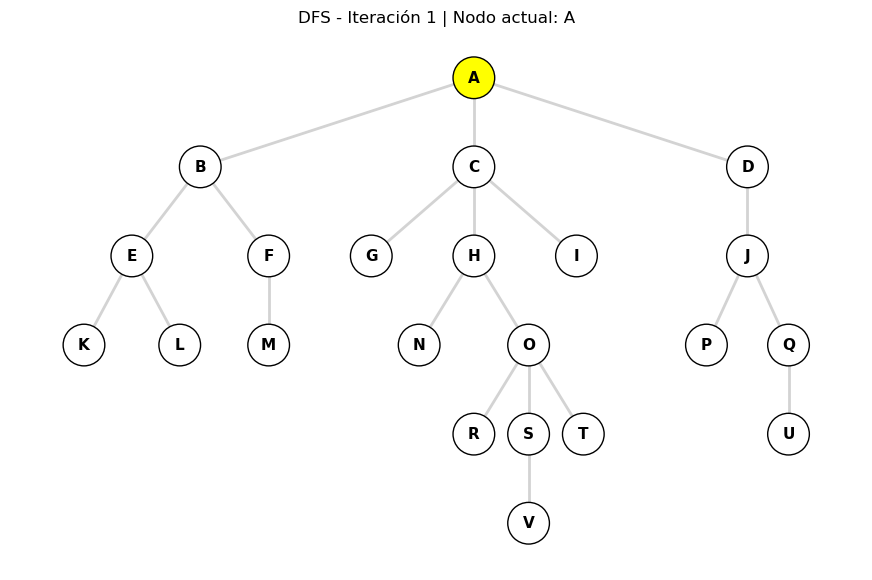

Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) | (B, A -> B) ]  <- tope

Iteración 2
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) | (B, A -> B) ]  <- tope
Nodo extraído: B
Camino actual: A -> B


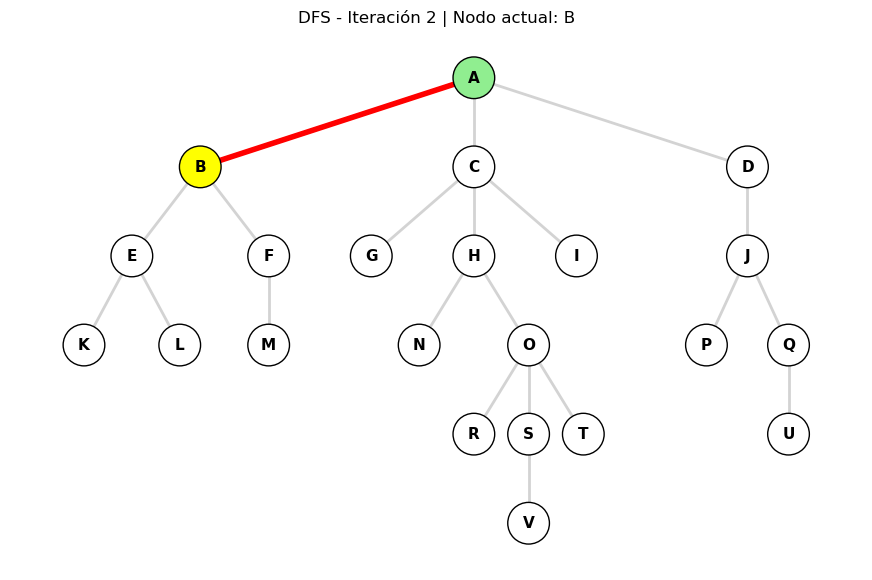

Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) | (E, A -> B -> E) ]  <- tope

Iteración 3
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) | (E, A -> B -> E) ]  <- tope
Nodo extraído: E
Camino actual: A -> B -> E


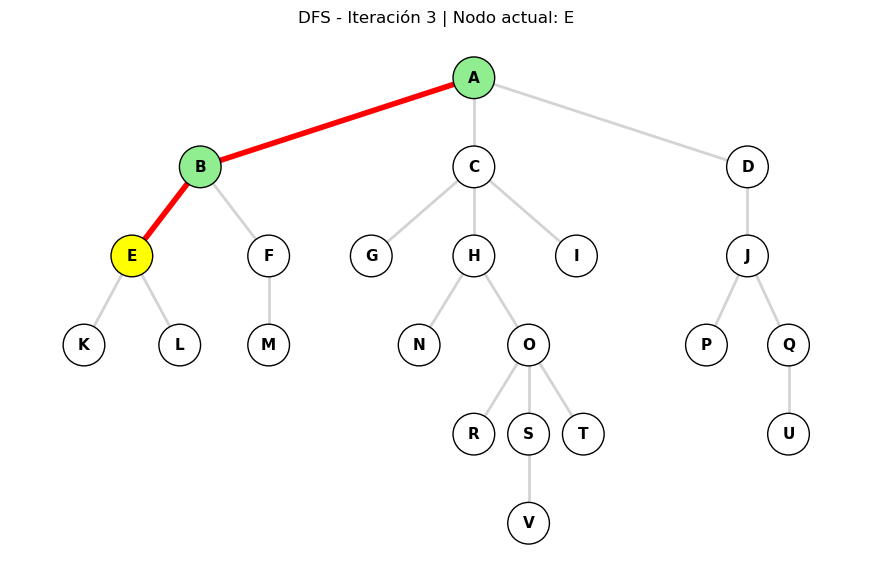

Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) | (L, A -> B -> E -> L) | (K, A -> B -> E -> K) ]  <- tope

Iteración 4
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) | (L, A -> B -> E -> L) | (K, A -> B -> E -> K) ]  <- tope
Nodo extraído: K
Camino actual: A -> B -> E -> K


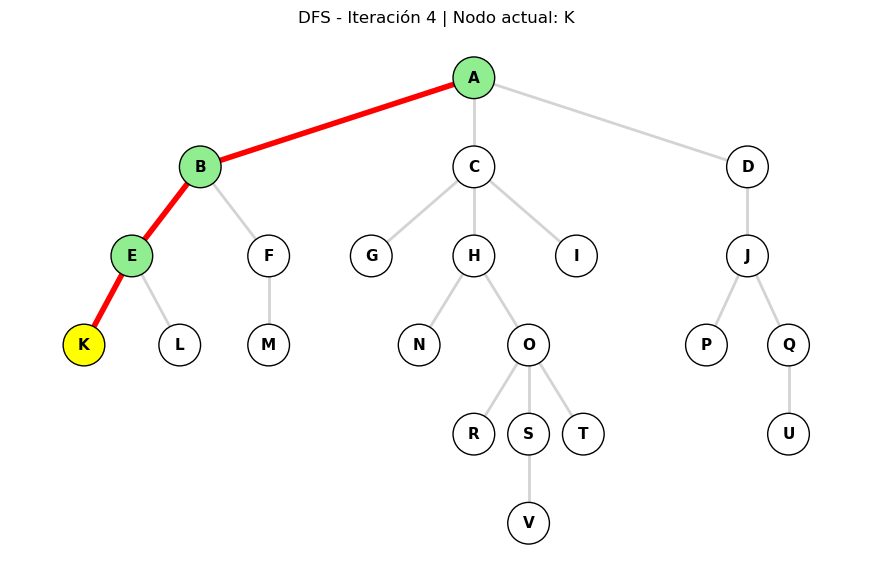

Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) | (L, A -> B -> E -> L) ]  <- tope

Iteración 5
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) | (L, A -> B -> E -> L) ]  <- tope
Nodo extraído: L
Camino actual: A -> B -> E -> L


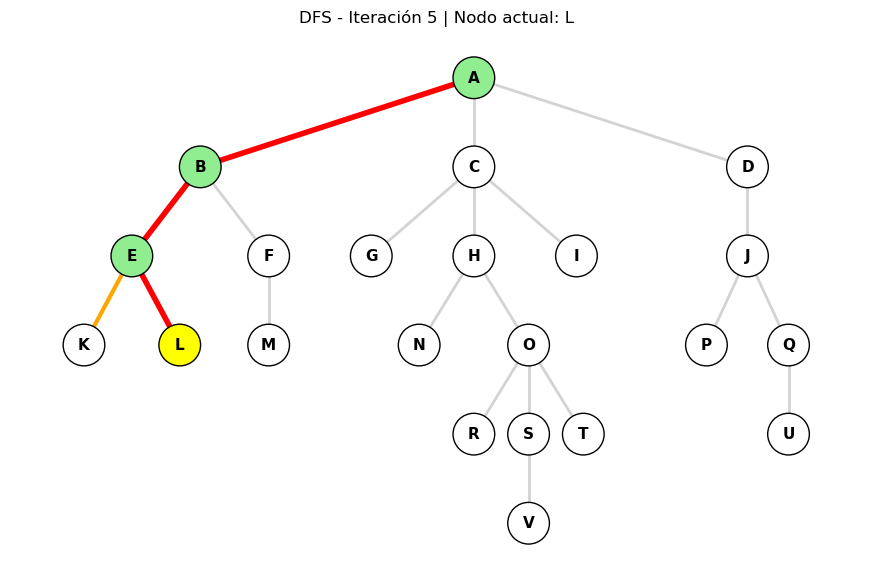

Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) ]  <- tope

Iteración 6
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) ]  <- tope
Nodo extraído: F
Camino actual: A -> B -> F


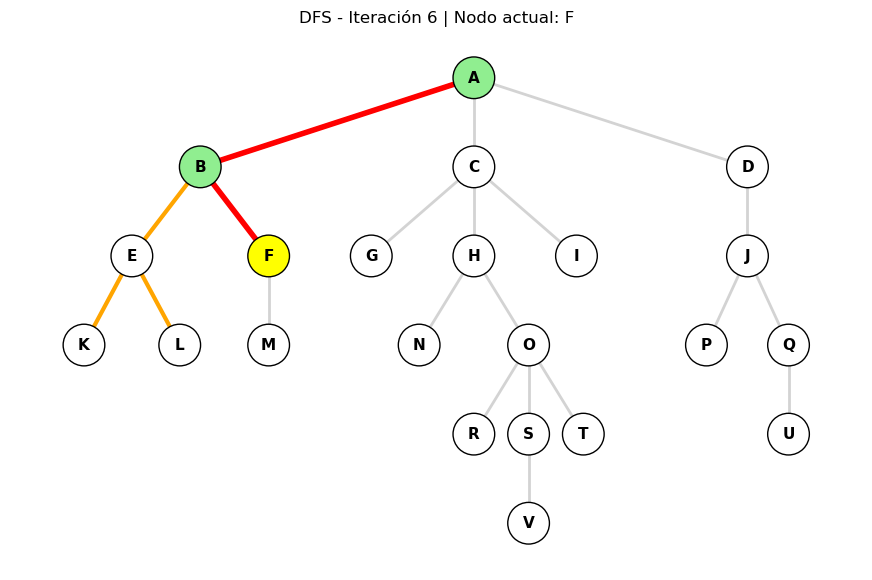

Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) | (M, A -> B -> F -> M) ]  <- tope

Iteración 7
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) | (M, A -> B -> F -> M) ]  <- tope
Nodo extraído: M
Camino actual: A -> B -> F -> M


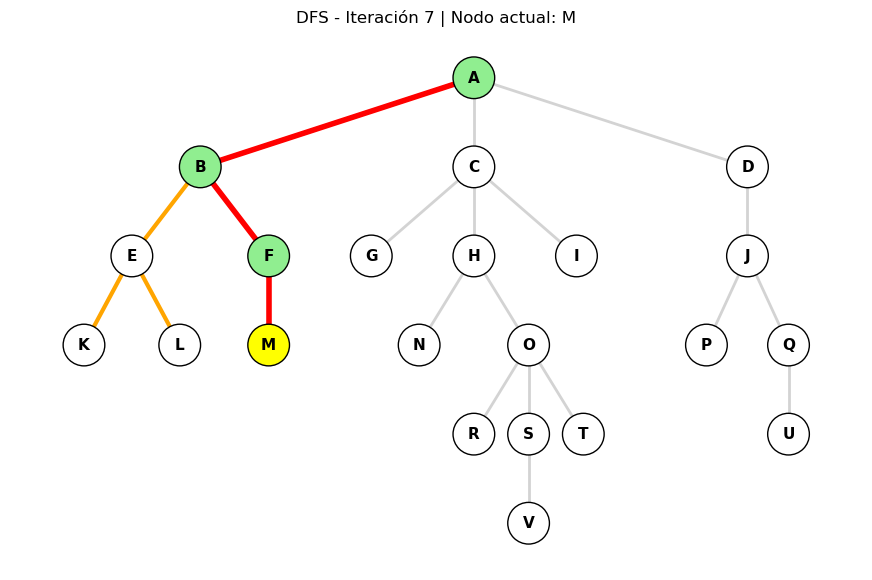

Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) ]  <- tope

Iteración 8
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) ]  <- tope
Nodo extraído: C
Camino actual: A -> C


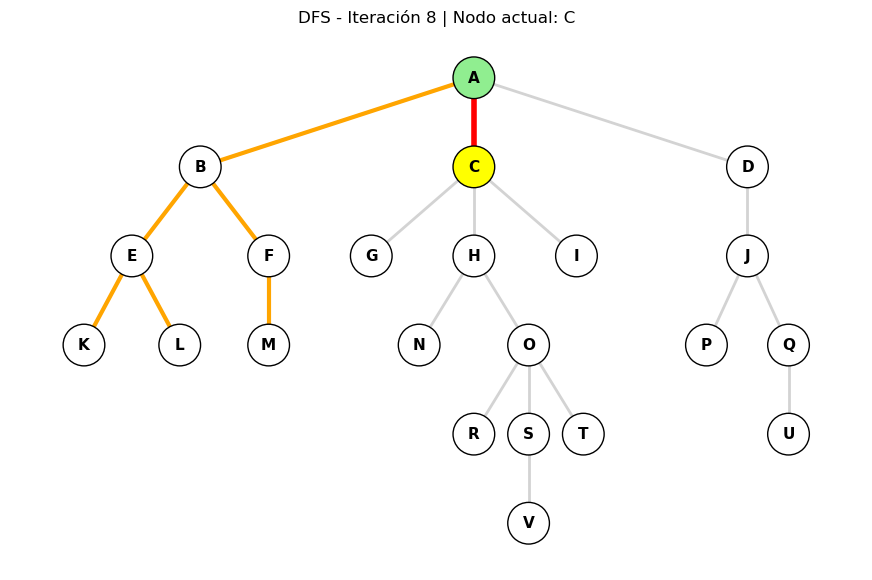

Pila después de agregar vecinos:
[ (D, A -> D) | (I, A -> C -> I) | (H, A -> C -> H) | (G, A -> C -> G) ]  <- tope

Iteración 9
Pila antes del pop:
[ (D, A -> D) | (I, A -> C -> I) | (H, A -> C -> H) | (G, A -> C -> G) ]  <- tope
Nodo extraído: G
Camino actual: A -> C -> G


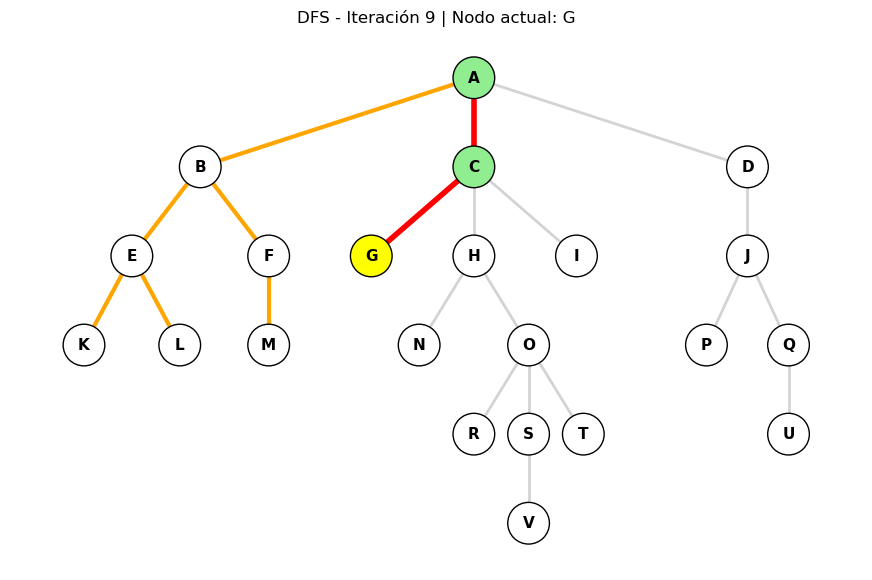


Objetivo encontrado.
Camino solución: A -> C -> G


In [18]:
camino_dfs = dfs(grafo, inicio, objetivo)

## LDFS

In [19]:
def ldfs(grafo, inicio, objetivo, limite, nombre="LDFS"):
    pila = [(inicio, [inicio])]
    aristas_recorridas = set()
    iteracion = 1

    print("\n==========================================")
    print(f" {nombre} - Búsqueda en Profundidad Limitada")
    print(f" Límite de profundidad: {limite}")
    print("==========================================")

    while pila:
        print(f"\nIteración {iteracion}")
        print("Pila antes del pop:")
        print(formatear_pila(pila))

        nodo, camino = pila.pop()
        profundidad = len(camino) - 1

        print(f"Nodo extraído: {nodo}")
        print(f"Camino actual: {formatear_camino(camino)}")
        print(f"Profundidad actual: {profundidad}")

        for arista in aristas_de_camino(camino):
            aristas_recorridas.add(arista)

        dibujar_grafo(
            titulo=f"{nombre} - Iteración {iteracion} | Nodo: {nodo} | Profundidad: {profundidad}",
            camino_actual=camino,
            aristas_recorridas=aristas_recorridas,
            nodo_actual=nodo
        )

        if nodo == objetivo:
            print("\nObjetivo encontrado.")
            print("Camino solución:", formatear_camino(camino))
            return camino

        if profundidad < limite:
            for vecino in reversed(grafo[nodo]):
                if vecino not in camino:
                    pila.append((vecino, camino + [vecino]))
        else:
            print("No se expanden vecinos porque se alcanzó el límite de profundidad.")

        print("Pila después de agregar vecinos:")
        print(formatear_pila(pila))

        iteracion += 1

    print("\nNo se encontró el objetivo con este límite.")
    return None



 LDFS - Búsqueda en Profundidad Limitada
 Límite de profundidad: 2

Iteración 1
Pila antes del pop:
[ (A, A) ]  <- tope
Nodo extraído: A
Camino actual: A
Profundidad actual: 0


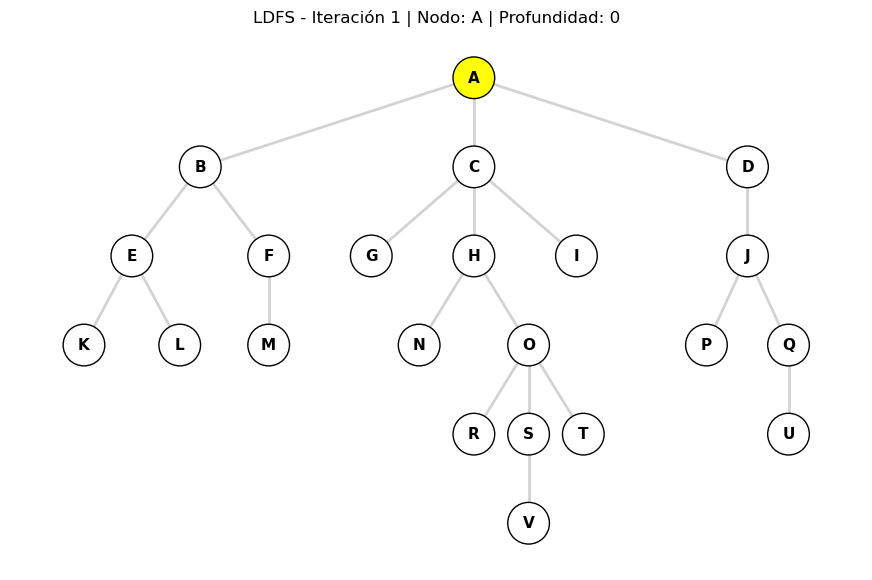

Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) | (B, A -> B) ]  <- tope

Iteración 2
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) | (B, A -> B) ]  <- tope
Nodo extraído: B
Camino actual: A -> B
Profundidad actual: 1


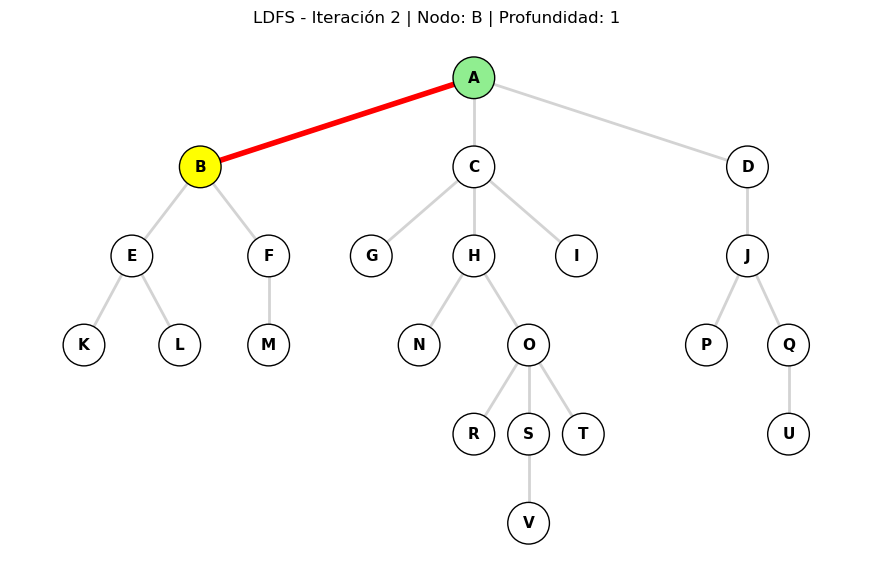

Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) | (E, A -> B -> E) ]  <- tope

Iteración 3
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) | (E, A -> B -> E) ]  <- tope
Nodo extraído: E
Camino actual: A -> B -> E
Profundidad actual: 2


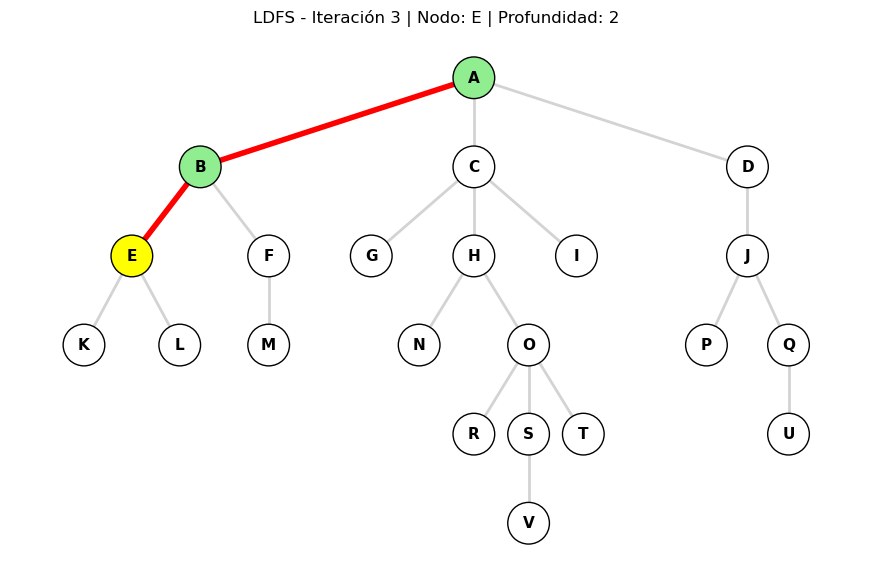

No se expanden vecinos porque se alcanzó el límite de profundidad.
Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) ]  <- tope

Iteración 4
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) ]  <- tope
Nodo extraído: F
Camino actual: A -> B -> F
Profundidad actual: 2


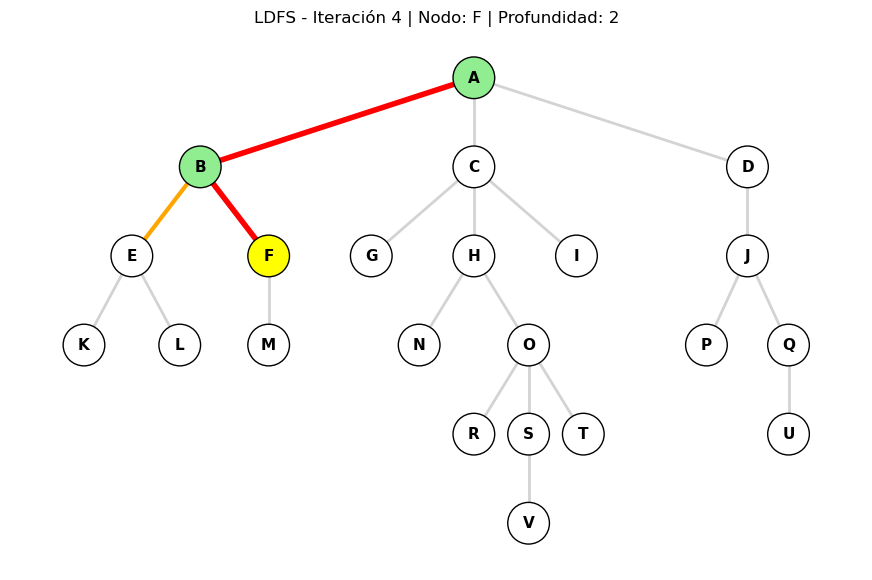

No se expanden vecinos porque se alcanzó el límite de profundidad.
Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) ]  <- tope

Iteración 5
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) ]  <- tope
Nodo extraído: C
Camino actual: A -> C
Profundidad actual: 1


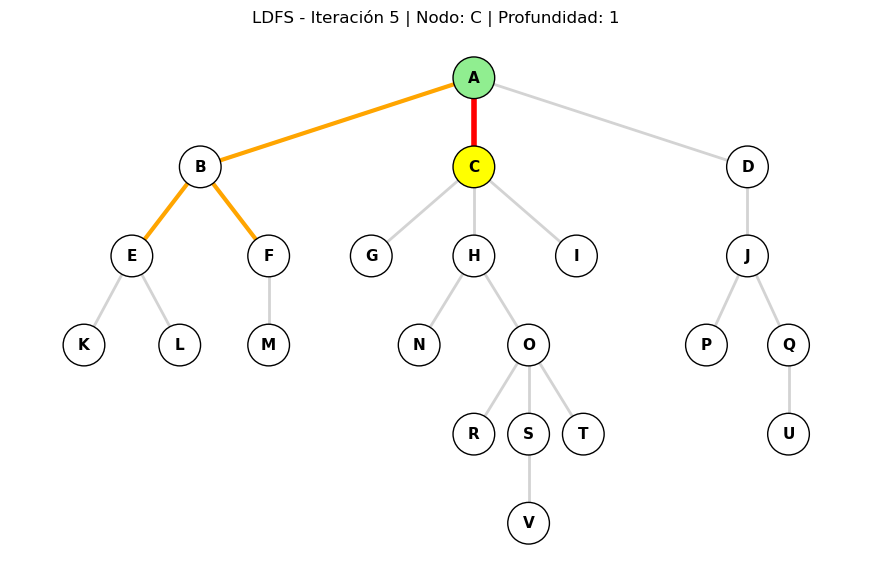

Pila después de agregar vecinos:
[ (D, A -> D) | (I, A -> C -> I) | (H, A -> C -> H) | (G, A -> C -> G) ]  <- tope

Iteración 6
Pila antes del pop:
[ (D, A -> D) | (I, A -> C -> I) | (H, A -> C -> H) | (G, A -> C -> G) ]  <- tope
Nodo extraído: G
Camino actual: A -> C -> G
Profundidad actual: 2


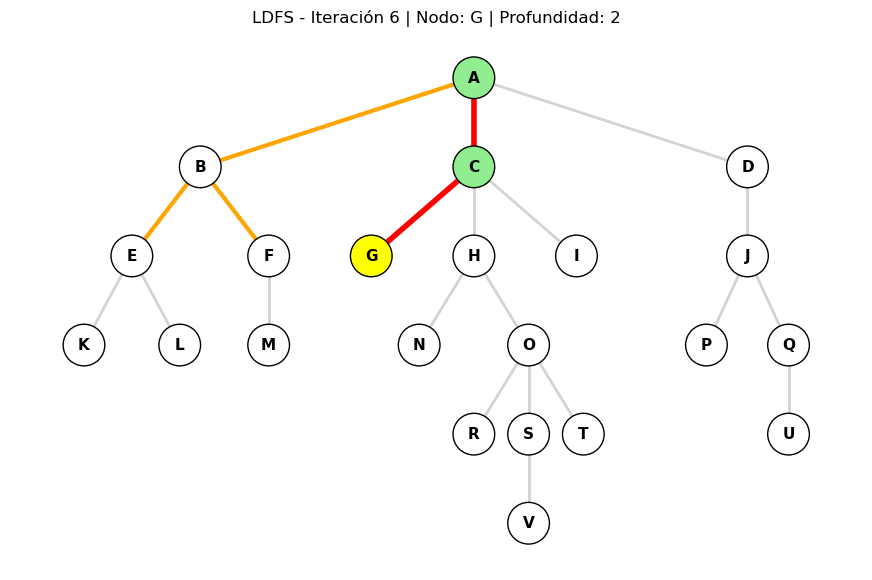


Objetivo encontrado.
Camino solución: A -> C -> G


In [20]:
camino_ldfs = ldfs(grafo, inicio, objetivo, limite=2)

## IDDFS

In [21]:
def idfs(grafo, inicio, objetivo, limite_maximo):
    print("\n==============================================")
    print(" IDFS - Búsqueda en Profundidad Iterativa")
    print("==============================================")

    for limite in range(limite_maximo + 1):
        print("\n\n##############################################")
        print(f" Ejecutando LDFS con límite = {limite}")
        print("##############################################")

        resultado = ldfs(
            grafo,
            inicio,
            objetivo,
            limite,
            nombre=f"IDFS con límite {limite}"
        )

        if resultado is not None:
            print("\nIDFS encontró el objetivo.")
            print("Camino solución:", formatear_camino(resultado))
            return resultado

    print("\nIDFS no encontró el objetivo dentro del límite máximo.")
    return None


 IDFS - Búsqueda en Profundidad Iterativa


##############################################
 Ejecutando LDFS con límite = 0
##############################################

 IDFS con límite 0 - Búsqueda en Profundidad Limitada
 Límite de profundidad: 0

Iteración 1
Pila antes del pop:
[ (A, A) ]  <- tope
Nodo extraído: A
Camino actual: A
Profundidad actual: 0


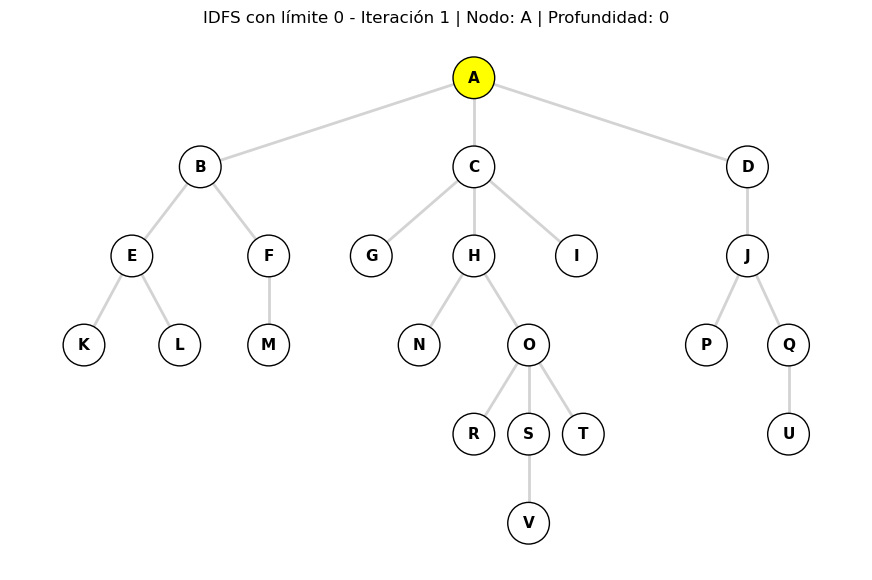

No se expanden vecinos porque se alcanzó el límite de profundidad.
Pila después de agregar vecinos:
[]

No se encontró el objetivo con este límite.


##############################################
 Ejecutando LDFS con límite = 1
##############################################

 IDFS con límite 1 - Búsqueda en Profundidad Limitada
 Límite de profundidad: 1

Iteración 1
Pila antes del pop:
[ (A, A) ]  <- tope
Nodo extraído: A
Camino actual: A
Profundidad actual: 0


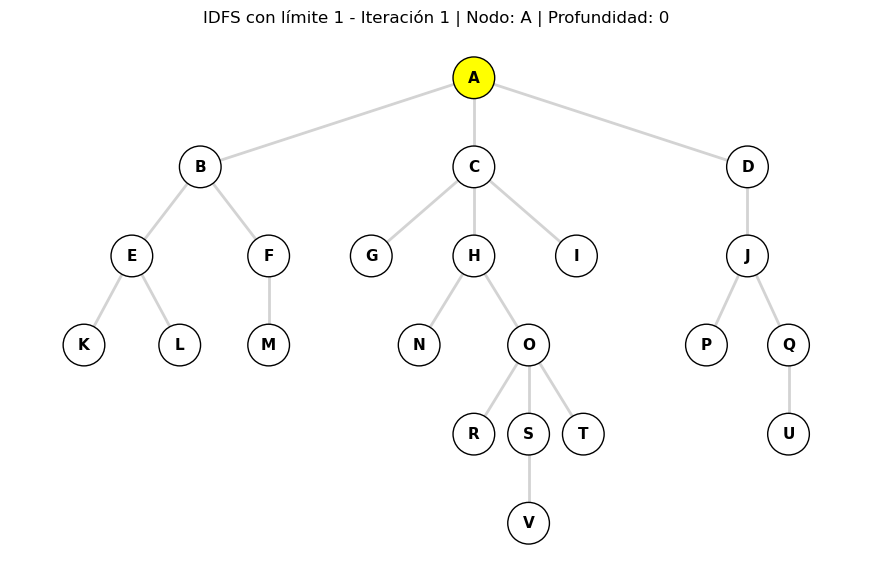

Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) | (B, A -> B) ]  <- tope

Iteración 2
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) | (B, A -> B) ]  <- tope
Nodo extraído: B
Camino actual: A -> B
Profundidad actual: 1


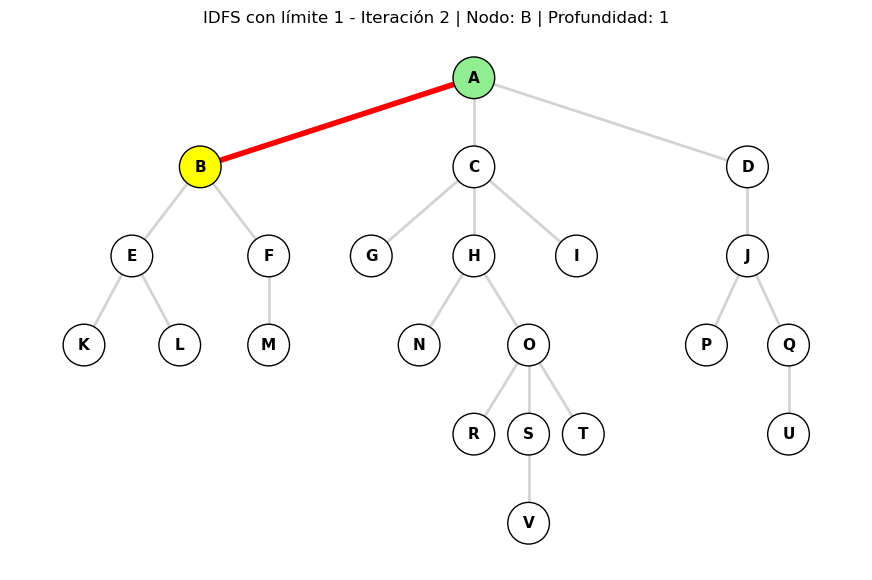

No se expanden vecinos porque se alcanzó el límite de profundidad.
Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) ]  <- tope

Iteración 3
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) ]  <- tope
Nodo extraído: C
Camino actual: A -> C
Profundidad actual: 1


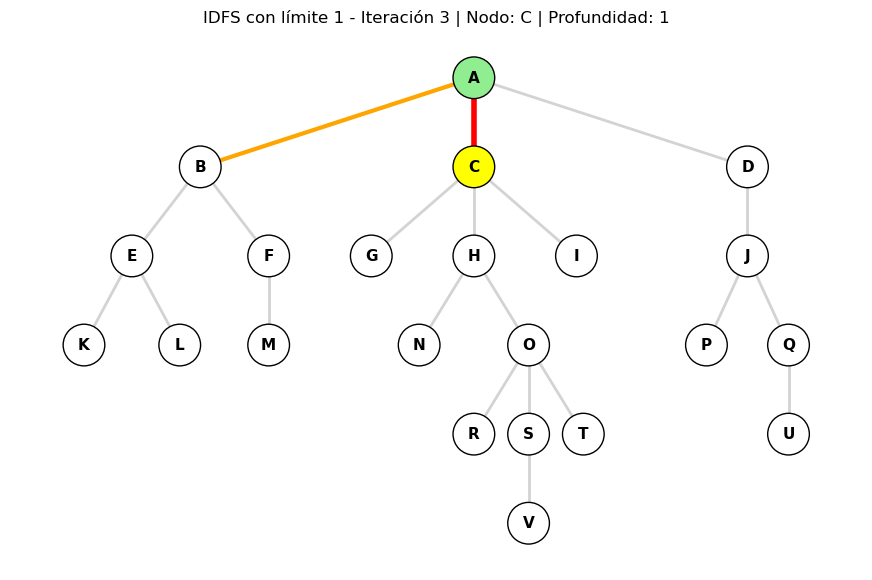

No se expanden vecinos porque se alcanzó el límite de profundidad.
Pila después de agregar vecinos:
[ (D, A -> D) ]  <- tope

Iteración 4
Pila antes del pop:
[ (D, A -> D) ]  <- tope
Nodo extraído: D
Camino actual: A -> D
Profundidad actual: 1


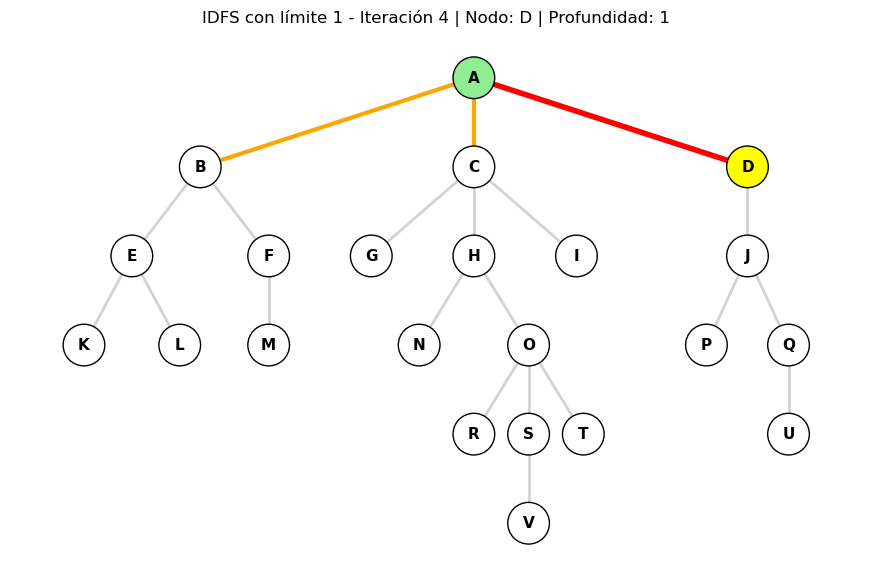

No se expanden vecinos porque se alcanzó el límite de profundidad.
Pila después de agregar vecinos:
[]

No se encontró el objetivo con este límite.


##############################################
 Ejecutando LDFS con límite = 2
##############################################

 IDFS con límite 2 - Búsqueda en Profundidad Limitada
 Límite de profundidad: 2

Iteración 1
Pila antes del pop:
[ (A, A) ]  <- tope
Nodo extraído: A
Camino actual: A
Profundidad actual: 0


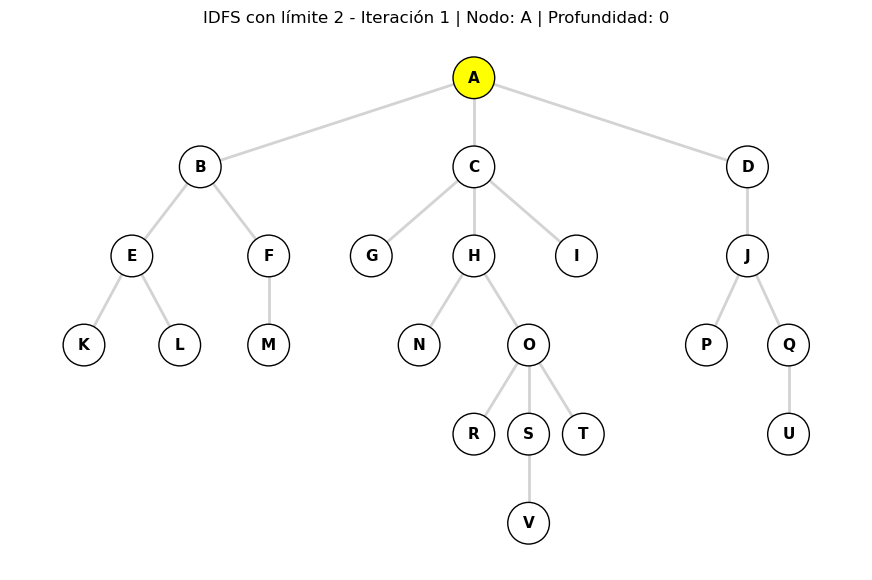

Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) | (B, A -> B) ]  <- tope

Iteración 2
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) | (B, A -> B) ]  <- tope
Nodo extraído: B
Camino actual: A -> B
Profundidad actual: 1


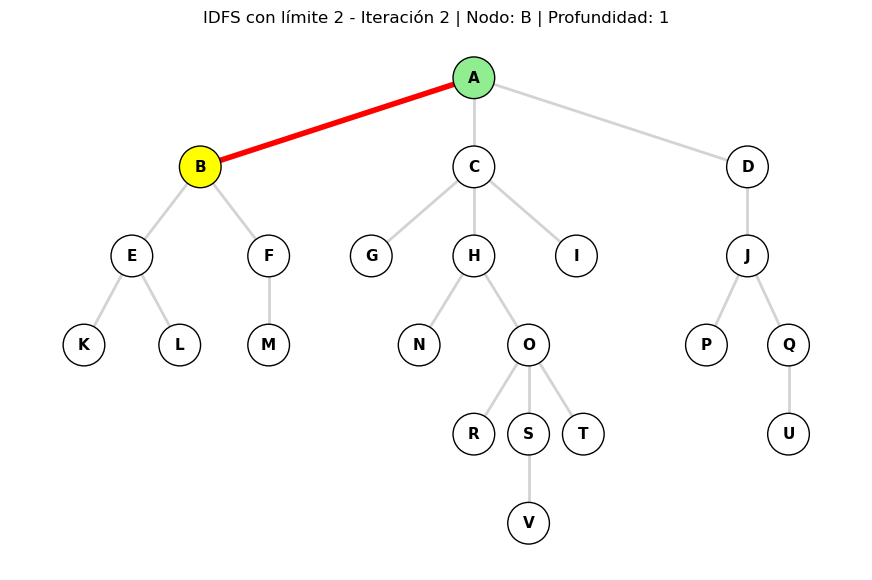

Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) | (E, A -> B -> E) ]  <- tope

Iteración 3
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) | (E, A -> B -> E) ]  <- tope
Nodo extraído: E
Camino actual: A -> B -> E
Profundidad actual: 2


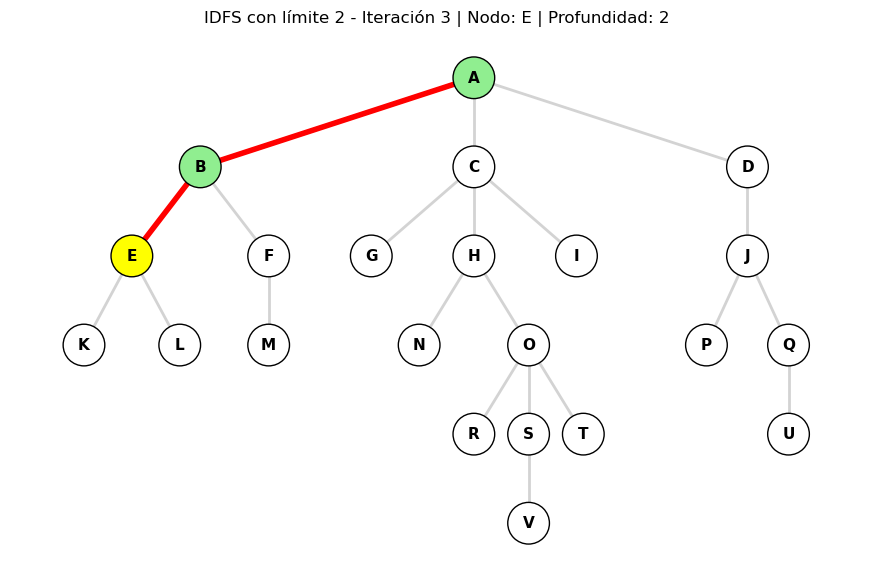

No se expanden vecinos porque se alcanzó el límite de profundidad.
Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) ]  <- tope

Iteración 4
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) | (F, A -> B -> F) ]  <- tope
Nodo extraído: F
Camino actual: A -> B -> F
Profundidad actual: 2


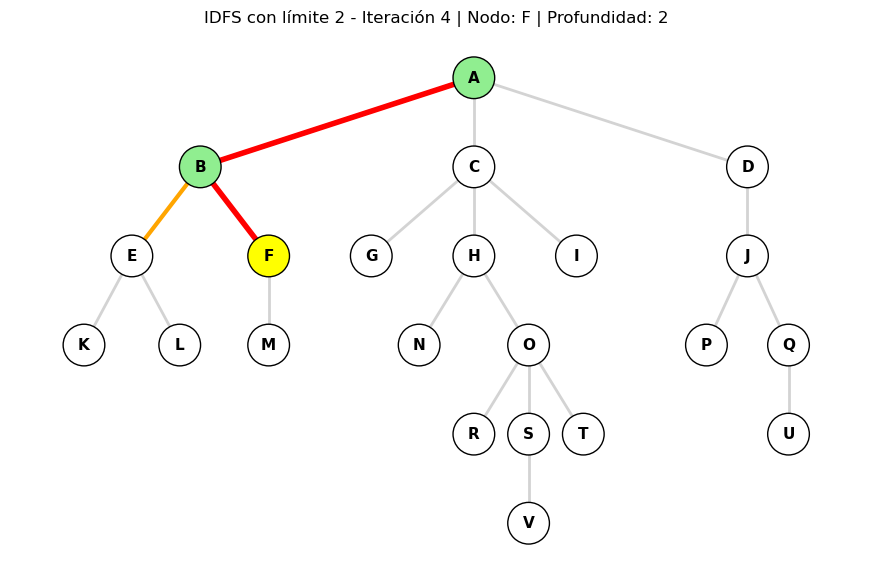

No se expanden vecinos porque se alcanzó el límite de profundidad.
Pila después de agregar vecinos:
[ (D, A -> D) | (C, A -> C) ]  <- tope

Iteración 5
Pila antes del pop:
[ (D, A -> D) | (C, A -> C) ]  <- tope
Nodo extraído: C
Camino actual: A -> C
Profundidad actual: 1


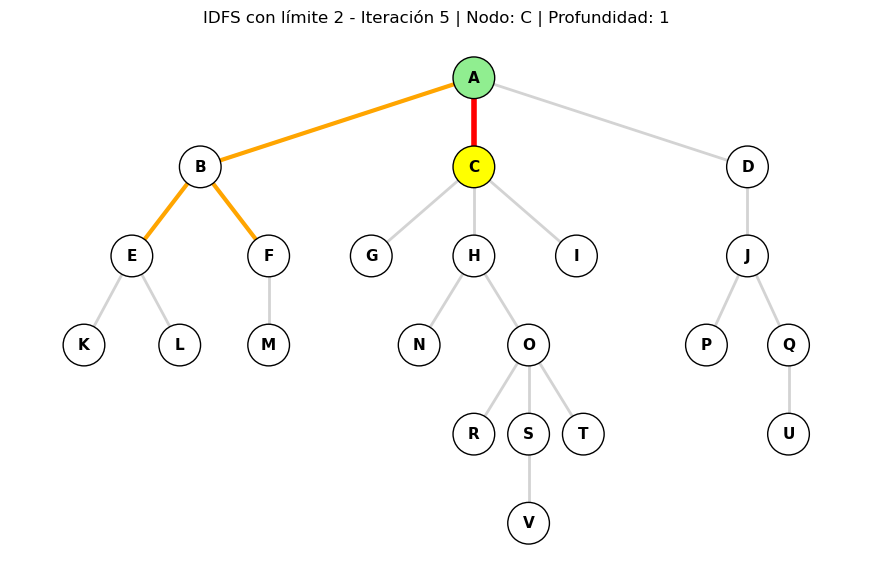

Pila después de agregar vecinos:
[ (D, A -> D) | (I, A -> C -> I) | (H, A -> C -> H) | (G, A -> C -> G) ]  <- tope

Iteración 6
Pila antes del pop:
[ (D, A -> D) | (I, A -> C -> I) | (H, A -> C -> H) | (G, A -> C -> G) ]  <- tope
Nodo extraído: G
Camino actual: A -> C -> G
Profundidad actual: 2


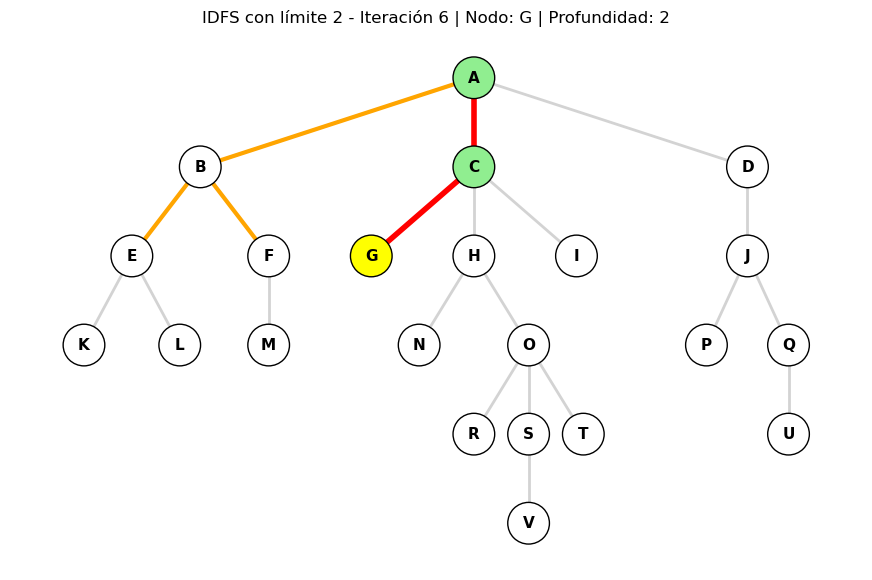


Objetivo encontrado.
Camino solución: A -> C -> G

IDFS encontró el objetivo.
Camino solución: A -> C -> G


In [22]:
camino_idfs = idfs(grafo, inicio, objetivo, limite_maximo=5)